In [16]:
import pandas as pd

# Load dataset
df = pd.read_csv("bank-additional-full.csv", sep=';')

# See first 5 rows
print(df.head())

# Check columns and data types
print(df.info())

# Summary statistics
print(df.describe())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

In [17]:
print(df['y'].value_counts(normalize=True))

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


In [18]:
# Check missing values
print(df.isnull().sum())

# Replace 'unknown' with NaN
df.replace('unknown', pd.NA, inplace=True)

# Fill missing values (simple way)
df.fillna(method='ffill', inplace=True)

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


/tmp/ipykernel_10326/3417907432.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [20]:
X = df.drop('y', axis=1)  # features
y = df['y']               # target

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)

print("Accuracy:", model1.score(X_test, y_test))

Accuracy: 0.911143481427531


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier()
model2.fit(X_train, y_train)

print("Accuracy:", model2.score(X_test, y_test))

Accuracy: 0.9139354212187424


In [24]:
from sklearn.ensemble import GradientBoostingClassifier

model3 = GradientBoostingClassifier()
model3.fit(X_train, y_train)

print("Accuracy:", model3.score(X_test, y_test))

Accuracy: 0.9201262442340374


In [25]:
# Conversion by contact type
print(df.groupby('contact')['y'].mean())

# Conversion by month
print(df.groupby('month')['y'].mean())

contact
0    0.147376
1    0.052313
Name: y, dtype: float64
month
0    0.204787
1    0.106021
2    0.489011
3    0.090466
4    0.105115
5    0.505495
6    0.064347
7    0.101439
8    0.438719
9    0.449123
Name: y, dtype: float64


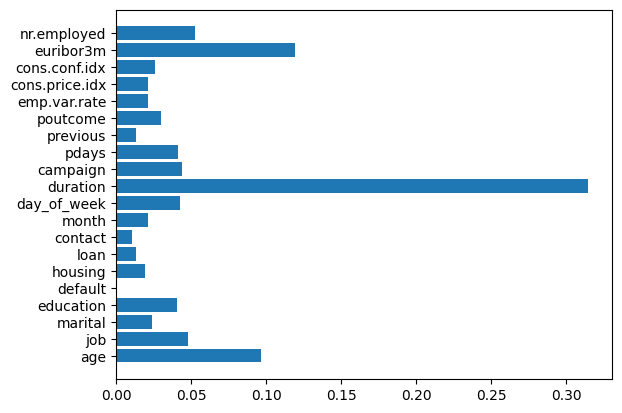

In [26]:
import matplotlib.pyplot as plt

importance = model2.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.show()

In [27]:
X = df.drop(['y', 'duration'], axis=1)

# New section